# 02 — Spectrograms and Short-Time Fourier Transform

In the previous notebook, we explored audio signals in the time domain using waveforms.

However, many important properties of sound are related to **frequency content**.

In this notebook, we will introduce the basic intuition behind:

1. Fourier Transform
2. Discrete Fourier Transform
3. Fast Fourier Transform
4. Short-Time Fourier Transform
5. Spectrograms

The goal is not to derive the full mathematical theory, but to understand what these tools allow us to see in audio signals.

A useful idea is:

```text
waveform     → what happens over time
spectrum     → what frequencies are present
spectrogram  → what frequencies are present over time
```

## Learning goals

By the end of this notebook, you should be able to explain:

- why a waveform is sometimes not enough to understand an audio signal;
- what information is shown by a spectrum;
- the difference between the DFT and the FFT;
- why we need the Short-Time Fourier Transform;
- how a spectrogram represents audio in time and frequency.

In [88]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio, display

In [89]:
PROJECT_ROOT = Path.cwd()

# If the notebook is launched from the notebooks folder,
# move one level up to the project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SUBSET_METADATA = PROJECT_ROOT / "data" / "processed" / "esc50_subset" / "esc50_subset_metadata.csv"

print("Project root:", PROJECT_ROOT)
print("Subset metadata:", SUBSET_METADATA)
print("Metadata exists:", SUBSET_METADATA.exists())

Project root: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class
Subset metadata: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/esc50_subset_metadata.csv
Metadata exists: True


## Plot style utilities

To keep the notebook concise and visually consistent, plotting style and reusable plotting functions are stored in:

```text
src/plot_config.py
```

In this notebook, we use the same style utilities introduced in the MFCC notebook.

In [90]:
import sys

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from plot_config import (
    apply_plot_style,
    clean_axes,
    GRAYSCALE,
    ACCENT,
    FIGSIZE_WIDE,
    DPI,
    plot_magnitude_spectrum,
)

apply_plot_style()


## Why do we need the frequency domain?

A waveform tells us how the amplitude of the signal changes over time.

This is useful, but it does not always tell us directly which frequencies are present in the sound.

For example, two signals may look complicated in the time domain, but their frequency content may be simple.

Fourier analysis helps us ask a different question:

> What frequencies are present in this signal?

## Pure tone in the time domain

A pure tone is one of the simplest audio signals.

It can be represented as a sinusoidal signal:

$$
x(t) = A \sin(2 \pi f t)
$$

where:

- $A$ is the amplitude,
- $f$ is the sound frequency in Hz,
- $t$ is time in seconds.

After sampling, we obtain a digital signal:

$$
x[n] = A \sin\left(2 \pi f \frac{n}{f_s}\right)
$$

where $f_s$ is the sampling rate.

In [91]:
sampling_rate = 22050  # samples per second
sound_frequency = 440  # Hz
duration_s = 1.0
amplitude = 0.8

t = np.arange(0, duration_s, 1 / sampling_rate)
x = amplitude * np.sin(2 * np.pi * sound_frequency * t)

print("Sampling rate:", sampling_rate, "Hz")
print("Sound frequency:", sound_frequency, "Hz")
print("Duration:", duration_s, "seconds")
print("Number of samples:", len(x))

Sampling rate: 22050 Hz
Sound frequency: 440 Hz
Duration: 1.0 seconds
Number of samples: 22050


In [92]:
display(Audio(x, rate=sampling_rate))

## Waveform of a pure tone

At 440 Hz, the signal oscillates 440 times per second.

If we plot the full second, the oscillations are too dense to inspect visually. Therefore, we plot only a short time window.

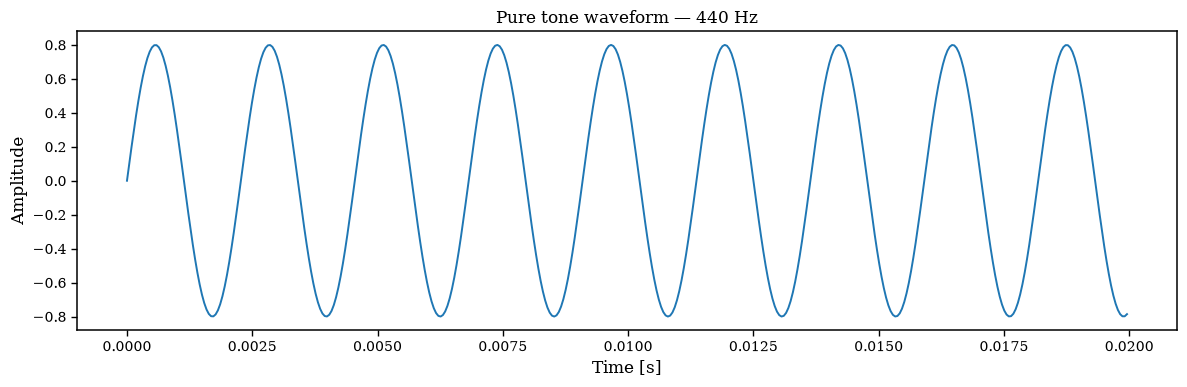

In [93]:
time_window = 0.02  # seconds
samples_to_plot = int(time_window * sampling_rate)

plt.figure(figsize=(12, 4))
plt.plot(t[:samples_to_plot], x[:samples_to_plot])
plt.title("Pure tone waveform — 440 Hz")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## From waveform to spectrum

The Fourier Transform represents a signal in terms of frequency components.

For a digital signal, we use the **Discrete Fourier Transform**.

The Discrete Fourier Transform maps a discrete-time signal $x[n]$ into a frequency-domain representation $X[k]$:

$$
X[k] = \sum_{n=0}^{N-1} x[n] e^{-j 2 \pi \,k\, n /N}
$$

In practical terms, $X[k]$ tells us how much of each frequency component is present in the signal.

The **Fast Fourier Transform** is an efficient algorithm to compute the DFT.

In Python, we can use:

```python
np.fft.rfft(x)
np.fft.rfftfreq(N, d=1/fs)
```

where:

- `np.fft.rfft(x)` computes the FFT for a real-valued signal,
- `np.fft.rfftfreq(...)` gives the frequency values associated with the FFT bins.

## FFT of a pure tone

A pure tone should produce one dominant peak in the spectrum.

Since our signal has a frequency of 440 Hz, we expect a peak near 440 Hz.

In [94]:
N = len(x)
fft_values = np.fft.rfft(x)
fft_magnitude = np.abs(fft_values)
frequencies = np.fft.rfftfreq(N, d=1 / sampling_rate)

peak_index = np.argmax(fft_magnitude)
peak_frequency = frequencies[peak_index]

print("Peak frequency:", peak_frequency, "Hz")

Peak frequency: 440.0 Hz


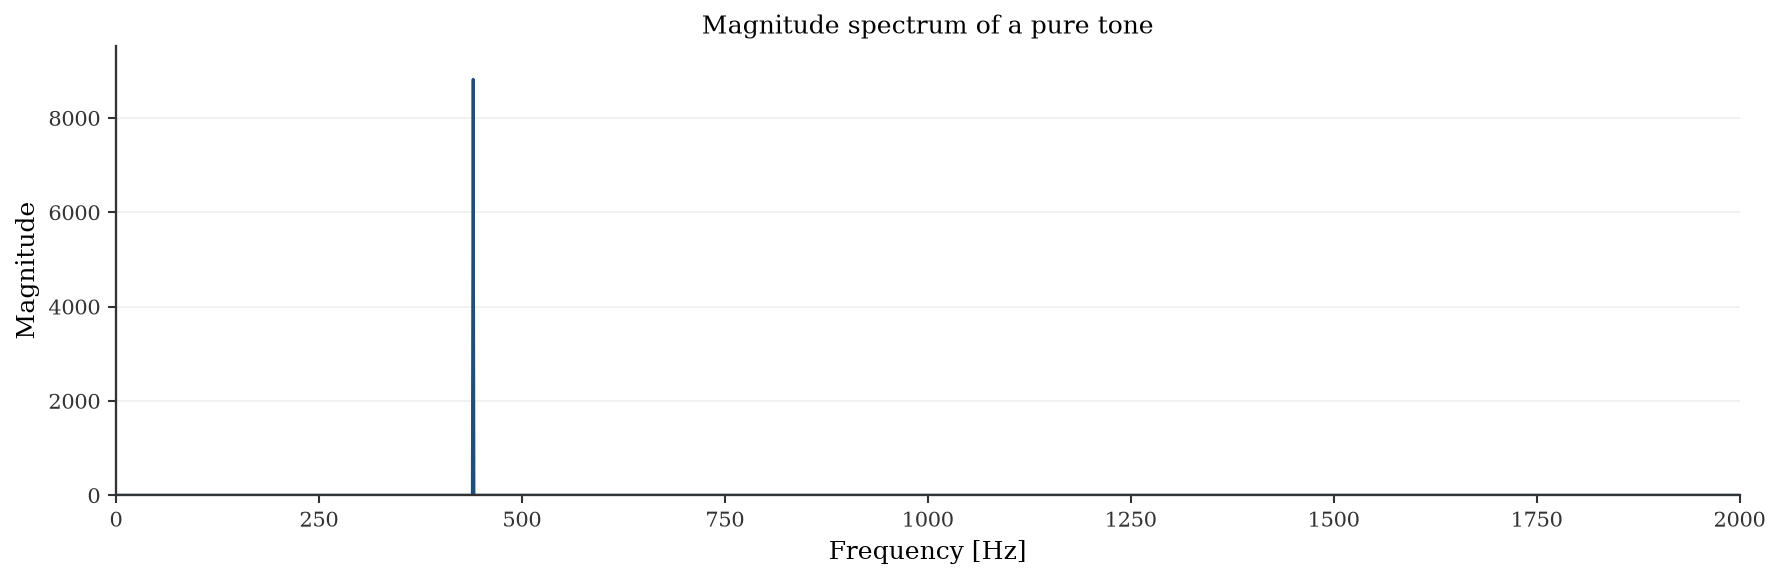

In [95]:
plot_magnitude_spectrum(
    frequencies=frequencies,
    magnitude=fft_magnitude,
    title="Magnitude spectrum of a pure tone",
    xlim=(0, 2000),
)

### Interpretation

The spectrum has one dominant peak close to 440 Hz.

This shows that a pure sinusoidal tone contains one dominant frequency component.

## Signal with multiple frequencies

Real sounds are usually more complex than a single pure tone.

To illustrate this, we can create a synthetic signal by adding several pure tones:

$$
x(t) = x_1(t) + x_2(t) + x_3(t)
$$

In this example, we combine 440 Hz, 880 Hz, and 1760 Hz.

In [96]:
frequencies_hz = [440, 880, 1760]
amplitudes = [0.8, 0.5, 0.3]

multi_tone = np.zeros_like(t)

for frequency, amp in zip(frequencies_hz, amplitudes):
    multi_tone += amp * np.sin(2 * np.pi * frequency * t)

# Normalize to avoid clipping in playback.
multi_tone = multi_tone / np.max(np.abs(multi_tone)) * 0.8

print("Frequencies:", frequencies_hz)
print("Duration:", duration_s, "seconds")
print("Number of samples:", len(multi_tone))

Frequencies: [440, 880, 1760]
Duration: 1.0 seconds
Number of samples: 22050


In [97]:
display(Audio(multi_tone, rate=sampling_rate))

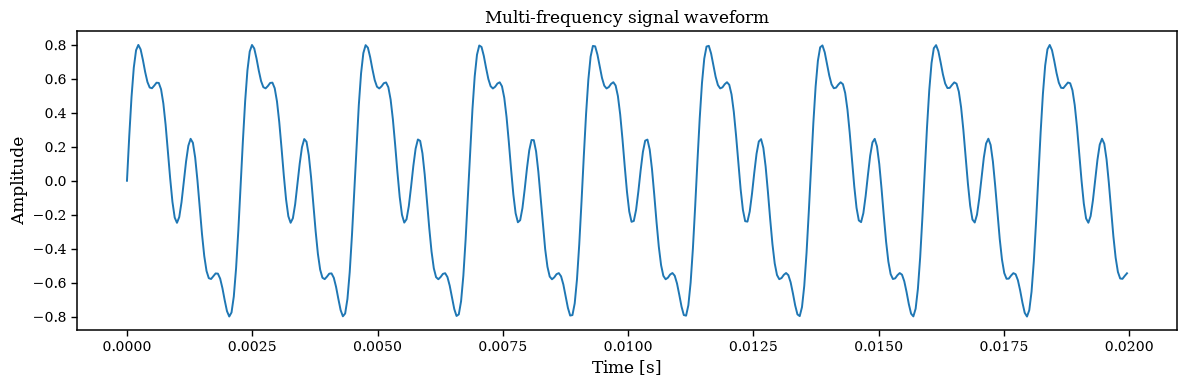

In [98]:
plt.figure(figsize=(12, 4))
plt.plot(t[:samples_to_plot], multi_tone[:samples_to_plot])
plt.title("Multi-frequency signal waveform")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## FFT of a multi-frequency signal

The waveform is now more complex, but the spectrum should reveal the frequencies used to construct the signal.

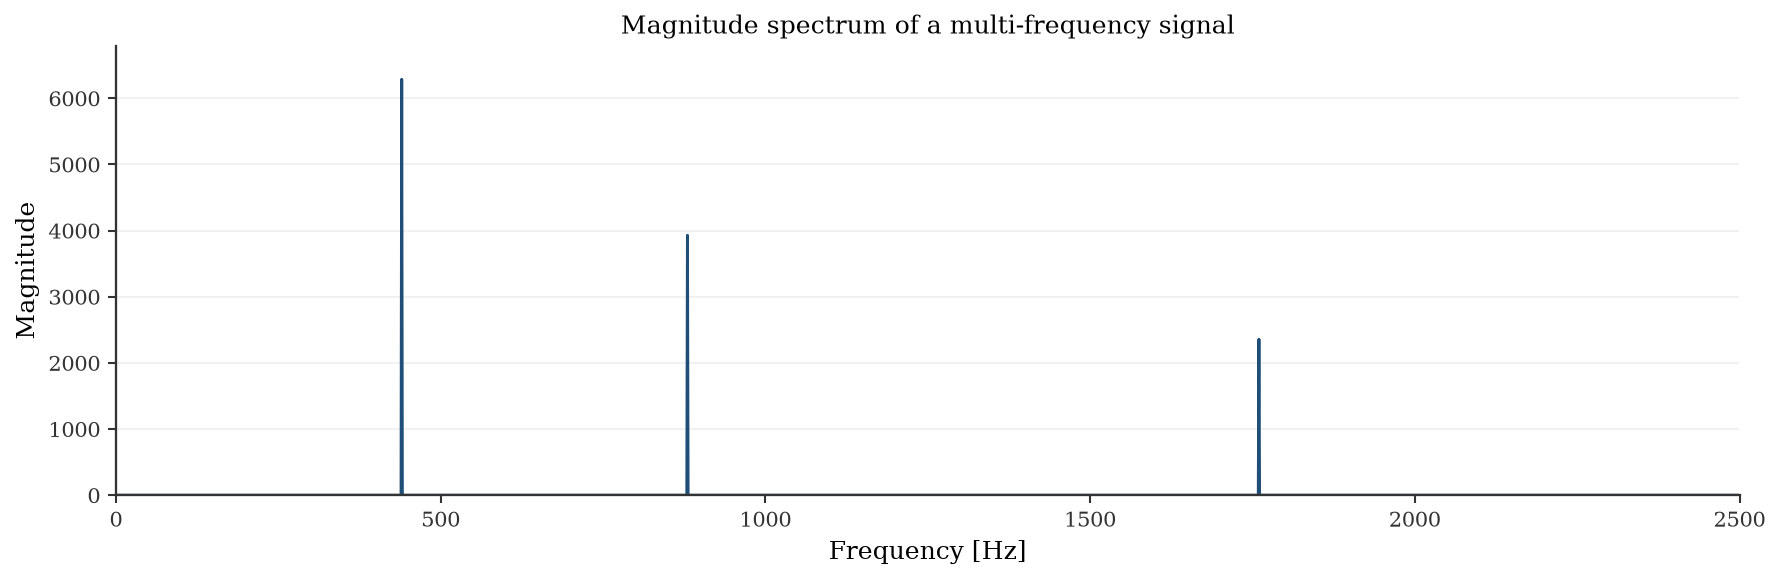

In [99]:
N = len(multi_tone)
fft_values = np.fft.rfft(multi_tone)
fft_magnitude = np.abs(fft_values)
frequencies = np.fft.rfftfreq(N, d=1 / sampling_rate)

plot_magnitude_spectrum(
    frequencies=frequencies,
    magnitude=fft_magnitude,
    title="Magnitude spectrum of a multi-frequency signal",
    xlim=(0, 2500),
)

### Interpretation

The FFT reveals several peaks corresponding to the frequency components of the signal.

This is the first key idea:

> The waveform may look complex, but the spectrum can reveal its frequency structure.

## Limitation of the global FFT

The FFT tells us what frequencies are present in the signal, but it does not tell us when they occur.

This becomes a problem when the frequency content changes over time.

To illustrate this, we will create a signal with three time segments:

1. first segment: 440 Hz,
2. second segment: 880 Hz,
3. third segment: 1760 Hz.

In [100]:
segment_duration = 1.0
segment_t = np.arange(0, segment_duration, 1 / sampling_rate)

segment_1 = np.sin(2 * np.pi * 440 * segment_t)
segment_2 = np.sin(2 * np.pi * 880 * segment_t)
segment_3 = np.sin(2 * np.pi * 1760 * segment_t)

changing_signal = np.concatenate([segment_3, segment_1, segment_2])
changing_signal = 0.8 * changing_signal / np.max(np.abs(changing_signal))

changing_duration = len(changing_signal) / sampling_rate
changing_t = np.arange(len(changing_signal)) / sampling_rate

print("Duration:", changing_duration, "seconds")
print("Number of samples:", len(changing_signal))

Duration: 3.0 seconds
Number of samples: 66150


In [101]:
display(Audio(changing_signal, rate=sampling_rate))

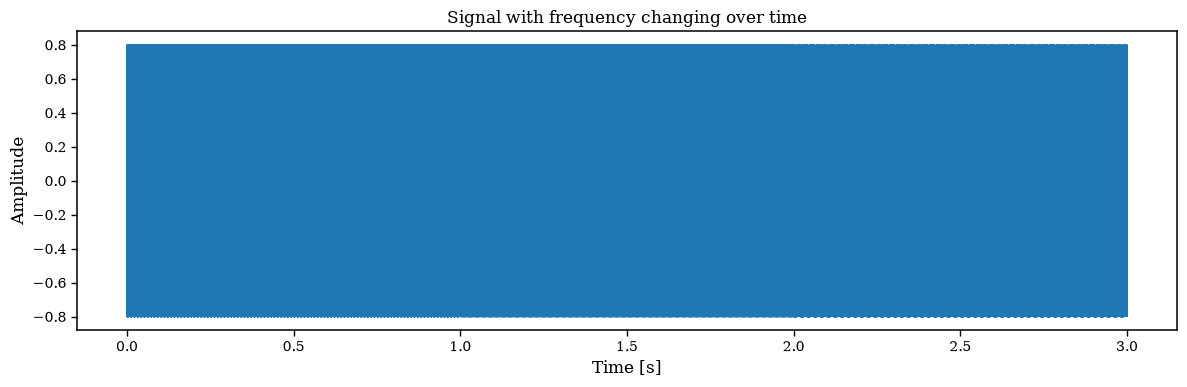

In [102]:
plt.figure(figsize=(12, 4))
plt.plot(changing_t, changing_signal)
plt.title("Signal with frequency changing over time")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Global FFT of a changing signal

The global FFT analyzes the entire signal at once.

It can identify that the signal contains 440 Hz, 880 Hz, and 1760 Hz, but it does not directly show when each frequency occurs.

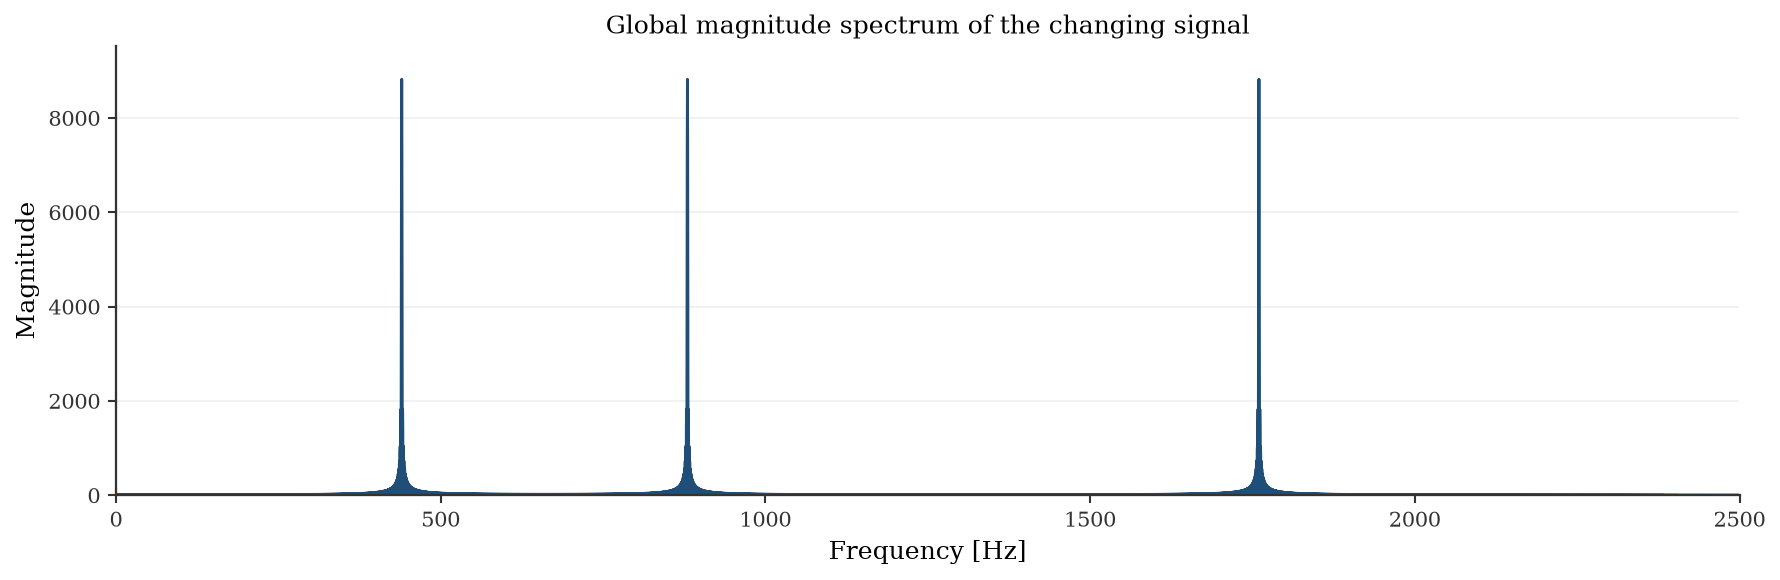

In [103]:
N = len(changing_signal)
fft_values = np.fft.rfft(changing_signal)
fft_magnitude = np.abs(fft_values)
frequencies = np.fft.rfftfreq(N, d=1 / sampling_rate)

plot_magnitude_spectrum(
    frequencies=frequencies,
    magnitude=fft_magnitude,
    title="Global magnitude spectrum of the changing signal",
    xlim=(0, 2500),
)

### Key limitation

The global spectrum tells us:

```text
The signal contains 440 Hz, 880 Hz, and 1760 Hz.
```

But it does not clearly tell us:

```text
440 Hz occurs first, 880 Hz occurs second, and 1760 Hz occurs third.
```

To recover this temporal information, we need a time-frequency representation.

## Short-Time Fourier Transform

The **Short-Time Fourier Transform** applies the Fourier Transform to short overlapping windows of the signal.

Instead of analyzing the entire signal at once, the STFT analyzes small time regions.

Conceptually:

```text
whole signal → short window → FFT
             → next window  → FFT
             → next window  → FFT
             → ...
```

The result tells us how the frequency content changes over time.

## STFT parameters

The main STFT parameters are:

- `n_fft`: size of the FFT window;
- `hop_length`: number of samples between consecutive windows;
- `window`: shape of the analysis window.

A useful intuition:

```text
larger window  → better frequency resolution, poorer time resolution
smaller window → better time resolution, poorer frequency resolution
```

This is one of the central trade-offs in time-frequency analysis.

## Visual intuition: sliding windows

The STFT can be understood with a simple computer-science idea:

```text
take a long array
select a short block
process that block
move the block forward
repeat
```

In audio, the long array is the digital signal $x[n]$.  
The short block is called a **window** or **frame**.

The important parameters are:

- **window length**: how many samples we analyze at once;
- **hop length**: how many samples we move forward to get the next window;
- **overlap**: how much two consecutive windows share.

If the hop length is smaller than the window length, the windows overlap.

### A playful analogy: reading a long sentence with a small ruler

Imagine that the audio signal is a very long sentence written on paper.

You cannot read the whole sentence at once.  
Instead, you place a small transparent ruler over part of the sentence, read that part, then move the ruler forward.

If you move the ruler by less than its own length, the new view overlaps with the previous one.

That is the idea of overlapping STFT windows.

In [104]:
# Toy example: sliding windows over a discrete array

n_samples_toy = 24
window_length_toy = 8
hop_length_toy = 4

starts = np.arange(
    0,
    n_samples_toy - window_length_toy + 1,
    hop_length_toy,
)

print("Toy signal length:", n_samples_toy, "samples")
print("Sample indices:", f"0 to {n_samples_toy - 1}")
print("Window length:", window_length_toy, "samples")
print("Hop length:", hop_length_toy, "samples")
print("Overlap:", window_length_toy - hop_length_toy, "samples")
print("Number of windows:", len(starts))
print("Window start indices:", starts)
print()

print("Window intervals using Python-style semi-open indexing:")
for i, start in enumerate(starts):
    end = start + window_length_toy
    included_first = start
    included_last = end - 1

    print(
        f"window {i}: [{start}, {end}) "
        f"→ samples {included_first} to {included_last}"
    )

Toy signal length: 24 samples
Sample indices: 0 to 23
Window length: 8 samples
Hop length: 4 samples
Overlap: 4 samples
Number of windows: 5
Window start indices: [ 0  4  8 12 16]

Window intervals using Python-style semi-open indexing:
window 0: [0, 8) → samples 0 to 7
window 1: [4, 12) → samples 4 to 11
window 2: [8, 16) → samples 8 to 15
window 3: [12, 20) → samples 12 to 19
window 4: [16, 24) → samples 16 to 23


### Reading the window intervals

A subtle but important detail is that the window intervals use the same logic as Python slicing:

```python
x[start:end]
```

This includes `start`, but excludes `end`.

For example, if a window starts at sample 0 and has length 8, the interval is:

\[
[0, 8)
\]

This means that the window includes samples:

```text
0, 1, 2, 3, 4, 5, 6, 7
```

It does **not** include sample 8.

Therefore:

```text
window 0: [0, 8)   → samples 0–7
window 1: [4, 12)  → samples 4–11
window 2: [8, 16)  → samples 8–15
window 3: [12, 20) → samples 12–19
window 4: [16, 24) → samples 16–23
```

In the figure, the right edge of the rectangle marks the boundary where the window ends.  
That boundary is not an included sample.

### Hop length and overlap with the same indexing logic

The `hop_length` tells us how far the window moves forward.

In this toy example:

```text
window_length = 8 samples
hop_length = 4 samples
```

The first window is:

```text
window 0: [0, 8)   → samples 0–7
```

Because `hop_length = 4`, the second window starts 4 samples later:

```text
window 1: [4, 12)  → samples 4–11
```

Now compare both windows:

```text
window 0: 0, 1, 2, 3, 4, 5, 6, 7
window 1:             4, 5, 6, 7, 8, 9, 10, 11
```

The shared samples are:

```text
4, 5, 6, 7
```

So the overlap is 4 samples.

Mathematically:

\[
\text{overlap} = \text{window length} - \text{hop length}
\]

\[
\text{overlap} = 8 - 4 = 4 \text{ samples}
\]

In short:

```text
hop_length → how far the window moves
overlap    → how many samples consecutive windows share
```

### Key point

The key point is that a rectangle ending at 8 does not mean that sample 8 is included.

It means that the window covers the interval:

\[
[0, 8)
\]

which includes exactly 8 samples:

```text
0, 1, 2, 3, 4, 5, 6, 7
```

This is the same convention used by Python slices.

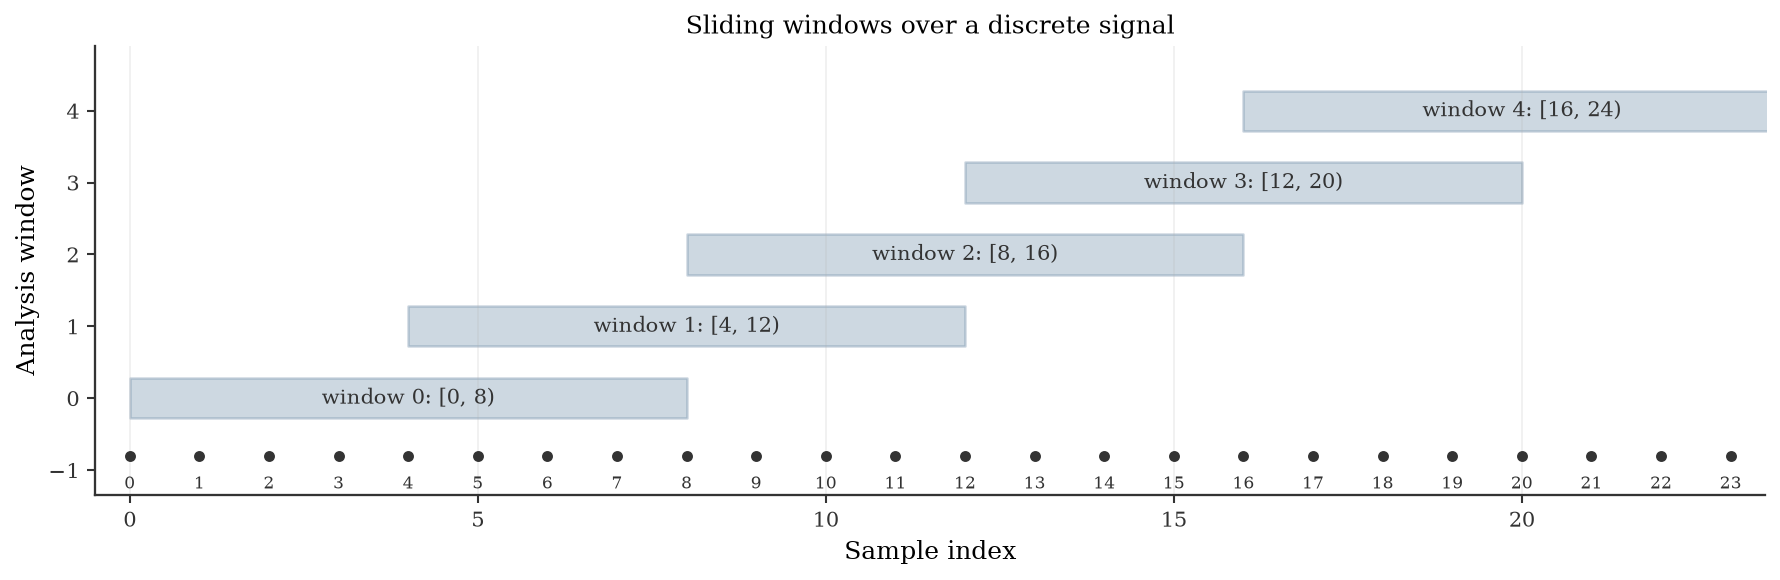

In [105]:
# Visualize sliding windows over a discrete signal

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

sample_indices = np.arange(n_samples_toy)

# Draw discrete sample positions.
ax.scatter(
    sample_indices,
    np.zeros_like(sample_indices) - 0.8,
    color=GRAYSCALE["dark"],
    s=18,
    zorder=3,
)

for sample_index in sample_indices:
    ax.text(
        sample_index,
        -1.08,
        str(sample_index),
        ha="center",
        va="top",
        fontsize=8,
        color=GRAYSCALE["dark"],
    )

# Draw analysis windows.
for i, start in enumerate(starts):
    end = start + window_length_toy

    ax.broken_barh(
        [(start, window_length_toy)],
        (i - 0.28, 0.56),
        facecolors=ACCENT["blue"],
        alpha=0.22,
        edgecolors=ACCENT["blue"],
        linewidth=1.2,
    )

    ax.text(
        start + window_length_toy / 2,
        i,
        f"window {i}: [{start}, {end})",
        ha="center",
        va="center",
        fontsize=10,
        color=GRAYSCALE["dark"],
    )

ax.set_title("Sliding windows over a discrete signal")
ax.set_xlabel("Sample index")
ax.set_ylabel("Analysis window")
ax.set_xlim(-0.5, n_samples_toy - 0.5)
ax.set_ylim(-1.35, len(starts) - 0.1)

clean_axes(ax, grid_axis="x")

plt.tight_layout()
plt.show()

### What happens inside each window?

For each window, the STFT does three things:

```text
1. Take a short segment of the signal
2. Multiply it by a smooth window shape
3. Compute an FFT for that segment
```

In pseudocode:

```python
for start in range(0, len(signal) - window_length, hop_length):
    frame = signal[start : start + window_length]
    frame = frame * window_shape
    spectrum = fft(frame)
```

Each FFT produces one spectrum.  
Putting all spectra side by side produces a time-frequency representation.

The second step is very important. The STFT usually does not analyze a segment with a hard rectangular cut. Instead, it multiplies the segment by a smooth window, such as a Hann window.

### Why do we multiply by a smooth window?

When we take a short segment from a longer signal, we are cutting the signal at the beginning and at the end of the frame.

A hard cut can introduce artificial discontinuities at the frame boundaries.

These discontinuities may create extra frequency components that were not really part of the original local signal. This effect is related to **spectral leakage**.

A smooth window reduces this problem by gradually fading the frame in and out:

```text
hard rectangular window → abrupt edges
smooth Hann window      → soft edges
```

The trade-off is that the window changes the signal amplitude inside the frame. However, it usually gives a cleaner and more stable local spectrum.

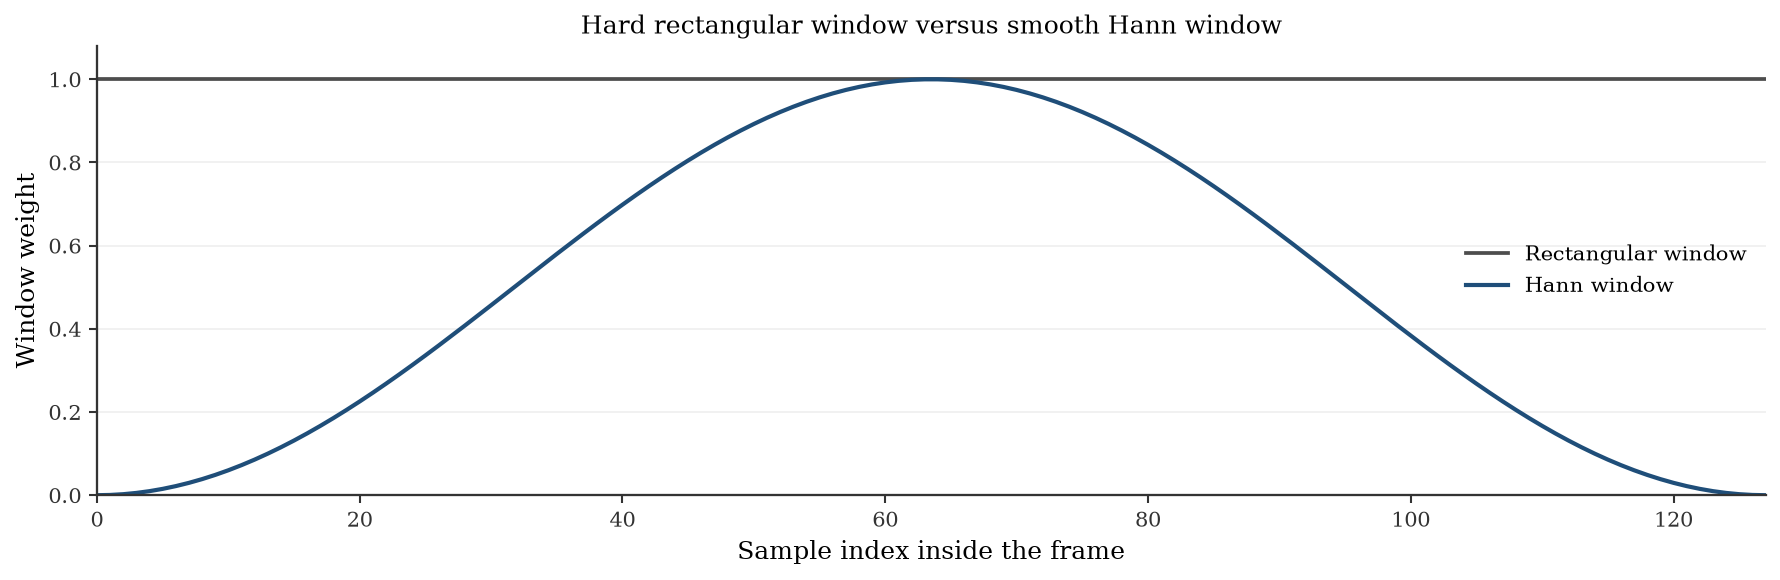

In [106]:
# Rectangular window versus Hann window

window_length_demo = 128
sample_index_demo = np.arange(window_length_demo)

rectangular_window = np.ones(window_length_demo)
hann_window = np.hanning(window_length_demo)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

ax.plot(
    sample_index_demo,
    rectangular_window,
    label="Rectangular window",
    color=GRAYSCALE["secondary"],
    linewidth=1.8,
)

ax.plot(
    sample_index_demo,
    hann_window,
    label="Hann window",
    color=ACCENT["blue"],
    linewidth=2.0,
)

ax.set_title("Hard rectangular window versus smooth Hann window")
ax.set_xlabel("Sample index inside the frame")
ax.set_ylabel("Window weight")
ax.set_xlim(0, window_length_demo - 1)
ax.set_ylim(0, 1.08)

clean_axes(ax, grid_axis="y")
ax.legend()

plt.tight_layout()
plt.show()

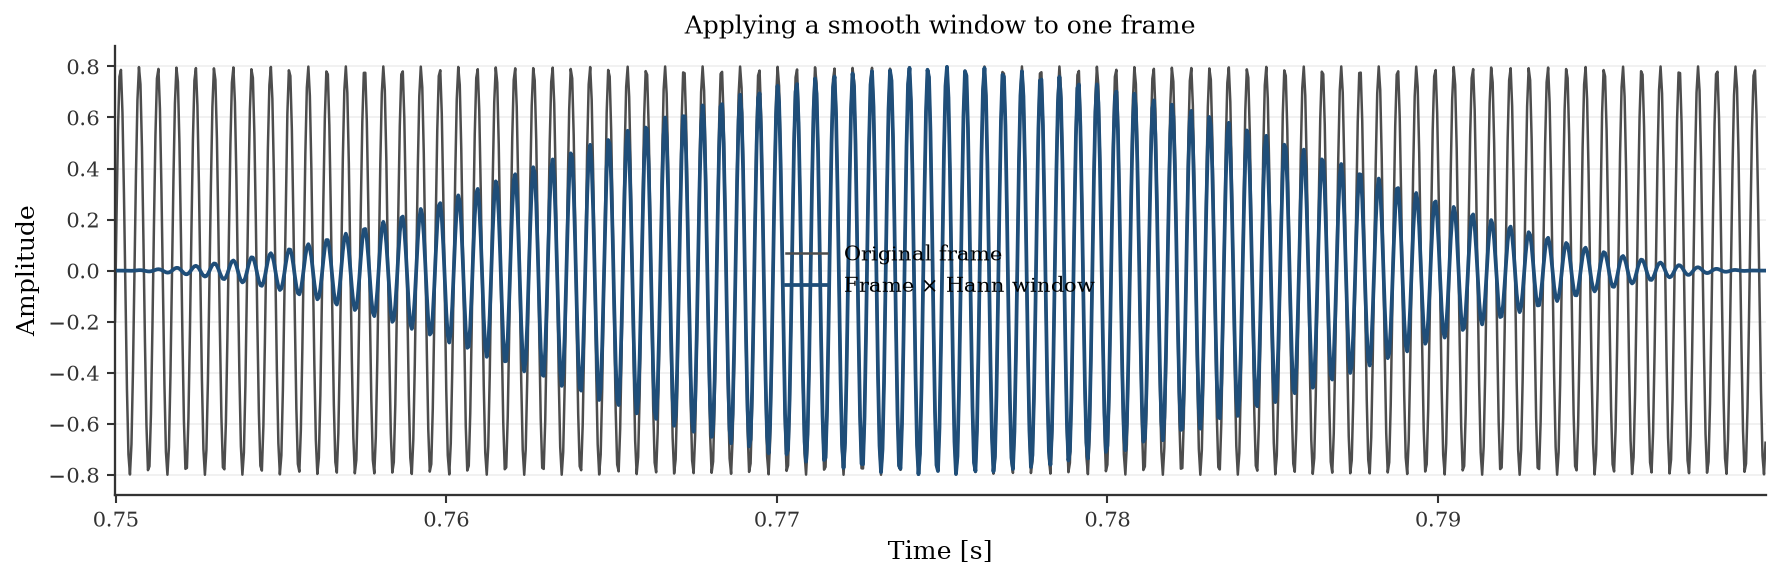

In [107]:
# Effect of a smooth window on one short signal frame

frame_duration_s = 0.05
frame_length = int(frame_duration_s * sampling_rate)

# Take a short frame from the changing signal.
start_sample = int(0.75 * sampling_rate)
end_sample = start_sample + frame_length

frame = changing_signal[start_sample:end_sample]
frame_time = changing_t[start_sample:end_sample]

hann = np.hanning(len(frame))
windowed_frame = frame * hann

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

ax.plot(
    frame_time,
    frame,
    label="Original frame",
    color=GRAYSCALE["secondary"],
    linewidth=1.2,
)

ax.plot(
    frame_time,
    windowed_frame,
    label="Frame × Hann window",
    color=ACCENT["blue"],
    linewidth=1.8,
)

ax.set_title("Applying a smooth window to one frame")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.set_xlim(frame_time[0], frame_time[-1])

clean_axes(ax, grid_axis="y")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation

The rectangular window keeps all samples with equal weight and then suddenly stops at the frame boundaries.

The Hann window gives high weight to the center of the frame and gradually reduces the weight near the edges.

This soft fade-in and fade-out reduces abrupt boundary effects before computing the FFT of the frame.

In simple terms:

```text
the smooth window prepares each short frame for a cleaner local frequency analysis
```

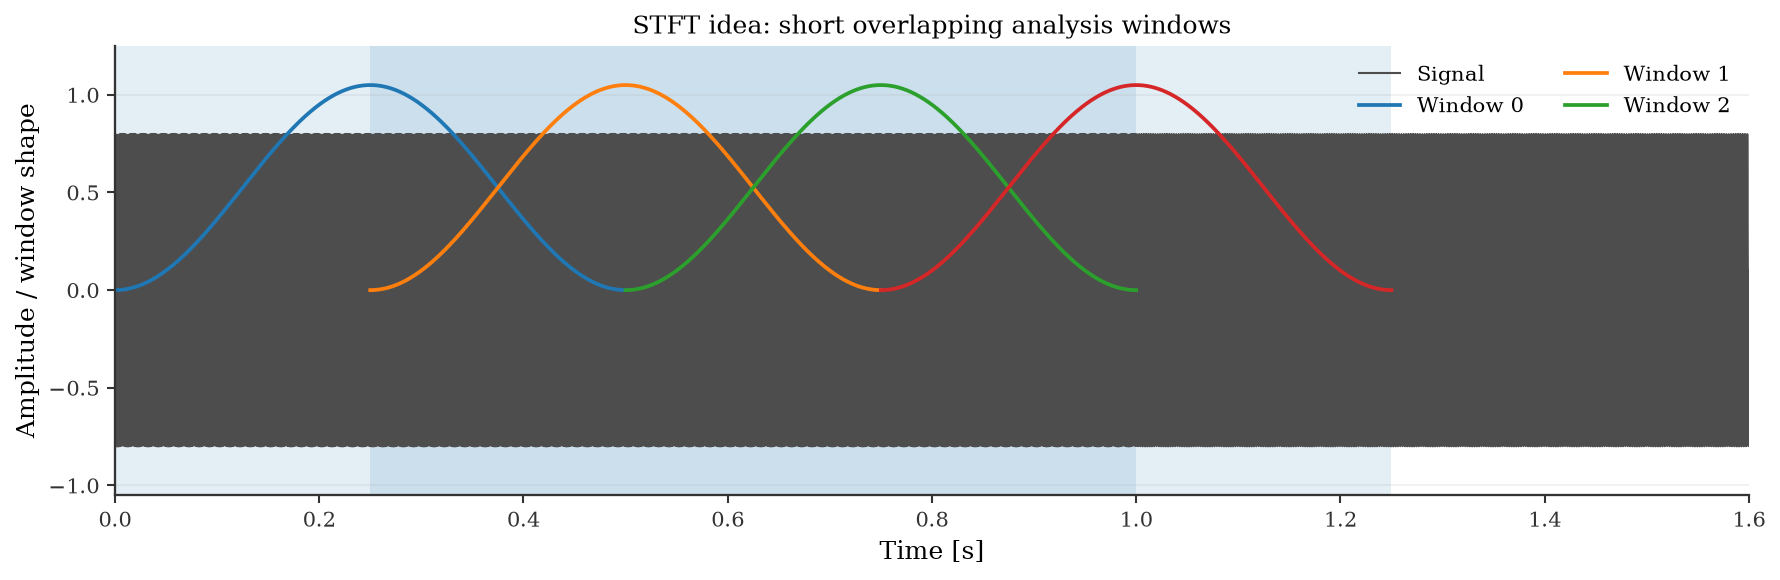

Window length: 11025 samples
Hop length: 5512 samples
Overlap: 5513 samples
Overlap percentage: 50.00453514739229 %


In [108]:
# Conceptual visualization of overlapping STFT windows on the changing signal

window_length_s = 0.50
hop_s = 0.25

window_length_samples = int(window_length_s * sampling_rate)
hop_samples = int(hop_s * sampling_rate)

window_shape = np.hanning(window_length_samples)

start_samples = [0, hop_samples, 2 * hop_samples, 3 * hop_samples]

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

ax.plot(
    changing_t,
    changing_signal,
    color=GRAYSCALE["secondary"],
    linewidth=1.0,
    label="Signal",
)

for i, start in enumerate(start_samples):
    end = start + window_length_samples
    start_time = start / sampling_rate
    end_time = end / sampling_rate

    # Shaded region: portion of signal analyzed by this window.
    ax.axvspan(start_time, end_time, alpha=0.12)

    # Draw the smooth Hann window shape above the signal.
    window_time = np.arange(start, end) / sampling_rate
    window_curve = 1.05 * window_shape / window_shape.max()
    ax.plot(
        window_time,
        window_curve,
        linewidth=1.8,
        label=f"Window {i}" if i < 3 else None,
    )

ax.set_title("STFT idea: short overlapping analysis windows")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude / window shape")
ax.set_xlim(0, 1.6)
ax.set_ylim(-1.05, 1.25)

clean_axes(ax, grid_axis="y")
ax.legend(ncol=2, loc="upper right")

plt.tight_layout()
plt.show()

print("Window length:", window_length_samples, "samples")
print("Hop length:", hop_samples, "samples")
print("Overlap:", window_length_samples - hop_samples, "samples")
print("Overlap percentage:", 100 * (window_length_samples - hop_samples) / window_length_samples, "%")

### Visual comparison: no overlap vs overlap

The following toy figure compares two ways of moving a window over a discrete signal.

- **No overlap:** the window moves by its full length.
- **75% overlap:** the window moves by only one quarter of its length.

This helps visualize why a smaller `hop_length` produces more analysis frames and a smoother time-frequency representation.

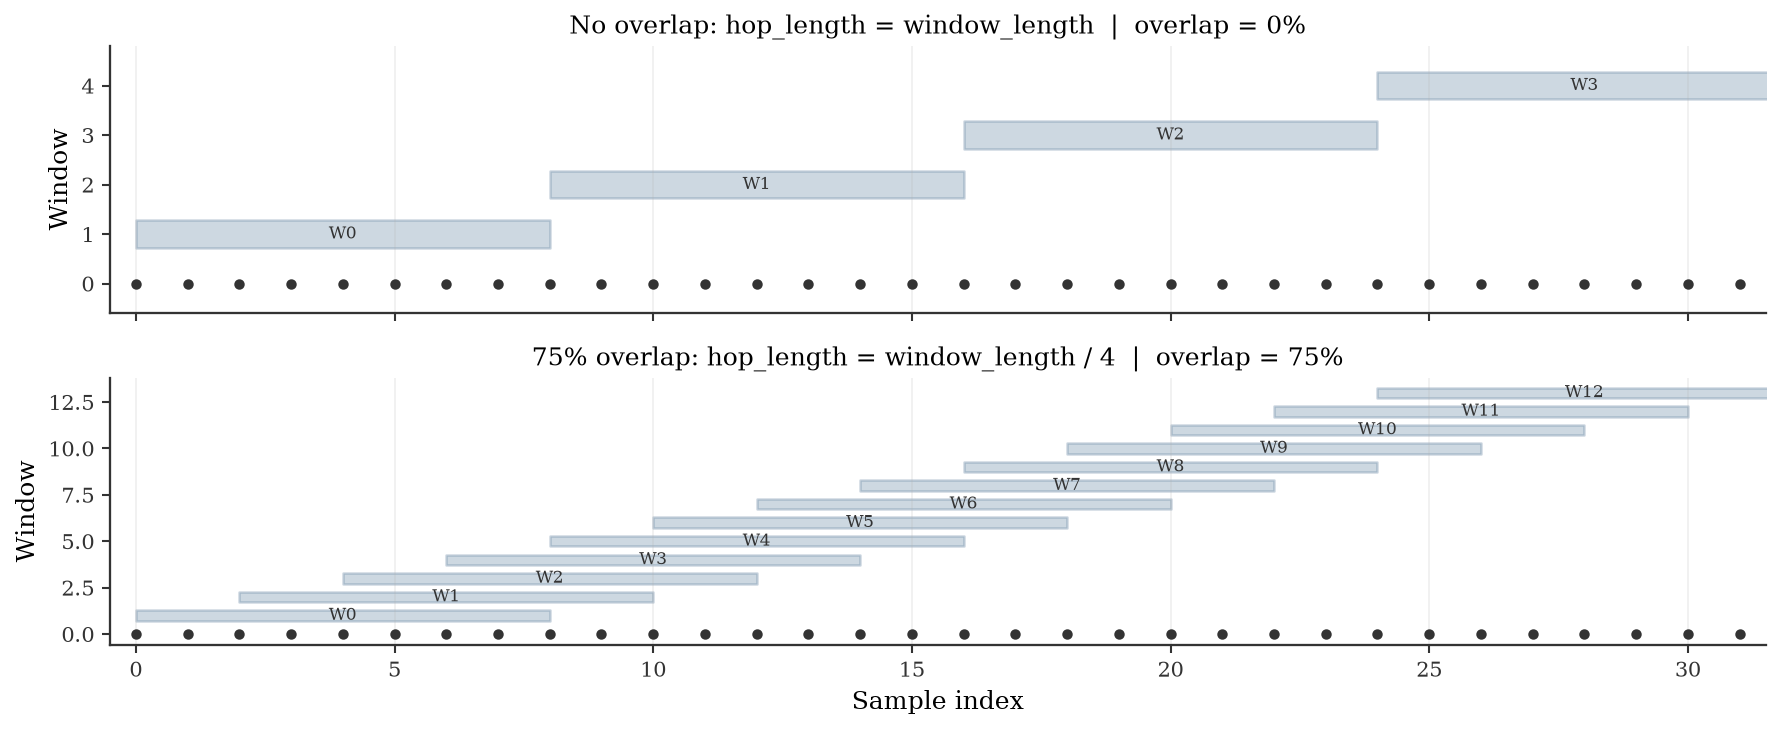

In [109]:
# Toy comparison of window movement with and without overlap

n_samples_toy = 32
window_length_toy = 8

hop_no_overlap = 8
hop_with_overlap = 2

starts_no_overlap = np.arange(
    0,
    n_samples_toy - window_length_toy + 1,
    hop_no_overlap,
)

starts_with_overlap = np.arange(
    0,
    n_samples_toy - window_length_toy + 1,
    hop_with_overlap,
)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), dpi=DPI, sharex=True)

cases = [
    ("No overlap: hop_length = window_length", starts_no_overlap, hop_no_overlap),
    ("75% overlap: hop_length = window_length / 4", starts_with_overlap, hop_with_overlap),
]

for ax, (title, starts, hop) in zip(axes, cases):
    sample_indices = np.arange(n_samples_toy)

    ax.scatter(
        sample_indices,
        np.zeros_like(sample_indices),
        color=GRAYSCALE["dark"],
        s=16,
        zorder=3,
    )

    for row, start in enumerate(starts):
        y_pos = row + 1

        ax.broken_barh(
            [(start, window_length_toy)],
            (y_pos - 0.28, 0.56),
            facecolors=ACCENT["blue"],
            alpha=0.22,
            edgecolors=ACCENT["blue"],
            linewidth=1.2,
        )

        ax.text(
            start + window_length_toy / 2,
            y_pos,
            f"W{row}",
            ha="center",
            va="center",
            fontsize=8,
            color=GRAYSCALE["dark"],
        )

    overlap_samples = window_length_toy - hop
    overlap_percent = overlap_samples / window_length_toy * 100

    ax.set_title(f"{title}  |  overlap = {overlap_percent:.0f}%")
    ax.set_ylabel("Window")
    ax.set_xlim(-0.5, n_samples_toy - 0.5)
    ax.set_ylim(-0.6, len(starts) + 0.8)

    clean_axes(ax, grid_axis="x")

axes[-1].set_xlabel("Sample index")

plt.tight_layout()
plt.show()

### Interpretation

The shaded regions show the portions of the signal analyzed by each STFT frame.

Because the hop length is smaller than the window length, consecutive windows overlap.

This overlap is useful because it avoids analyzing the signal in isolated, disconnected blocks.  
It gives a smoother description of how frequency content evolves over time.

In short:

```text
window length → how much signal each FFT sees
hop length    → how far the window moves
overlap       → how much consecutive windows share
```

## Why do we use overlap?

In the Short-Time Fourier Transform, we analyze the signal using short windows.

Two parameters control how the analysis moves through time:

- `window_length`: how many samples are included in each analysis window;
- `hop_length`: how many samples the window moves forward before computing the next spectrum.

The important point is:

```text
hop_length is not the overlap.
hop_length is the step size between consecutive windows.
```

Overlap appears when the hop length is smaller than the window length:

\[
\text{overlap} = \text{window length} - \text{hop length}
\]

For example, if:

```python
window_length = 2048
hop_length = 512
```

then:

\[
\text{overlap} = 2048 - 512 = 1536 \text{ samples}
\]

and the overlap percentage is:

\[
\frac{1536}{2048} = 0.75 = 75\%
\]

### Why is this useful?

Audio signals change over time. If the analysis window jumps too far, important events may fall between two windows or may be represented too coarsely.

Overlap allows neighboring windows to share part of the signal. This gives a smoother and more continuous description of how the frequency content evolves over time.

In short:

```text
smaller hop_length → more overlap → smoother time tracking → more computation
larger hop_length  → less overlap → coarser time tracking  → less computation
```

### Intuitive analogy

Imagine reading a long text using a small sliding window.

If you move the window by its full length every time, each piece of text is read only once.

But if you move the window by a smaller step, consecutive windows share some words.

This overlap helps preserve context between neighboring windows.

The STFT does something similar with audio:

```text
audio signal → short window → FFT
             → move window by hop_length
             → FFT again
             → repeat
```

Overlap helps avoid analyzing each frame as if it were completely independent from the next one.

In [110]:
# Mini example: window length, hop length, and overlap

window_length = 2048
hop_length = 512

overlap = window_length - hop_length
overlap_percentage = overlap / window_length * 100

print("Window length:", window_length, "samples")
print("Hop length:", hop_length, "samples")
print("Overlap:", overlap, "samples")
print("Overlap percentage:", f"{overlap_percentage:.1f}%")

Window length: 2048 samples
Hop length: 512 samples
Overlap: 1536 samples
Overlap percentage: 75.0%


### In summary

`hop_length` controls how much the analysis window advances.

When `hop_length` is smaller than the window length, consecutive windows overlap.

This overlap helps the STFT track changes in audio more smoothly over time, at the cost of computing more FFTs.

## Spectrogram of the changing signal

A spectrogram is a visual representation of the STFT magnitude.

It shows:

- time on the x-axis,
- frequency on the y-axis,
- magnitude or energy using color.

In other words:

```text
spectrogram = how frequency content changes over time
```

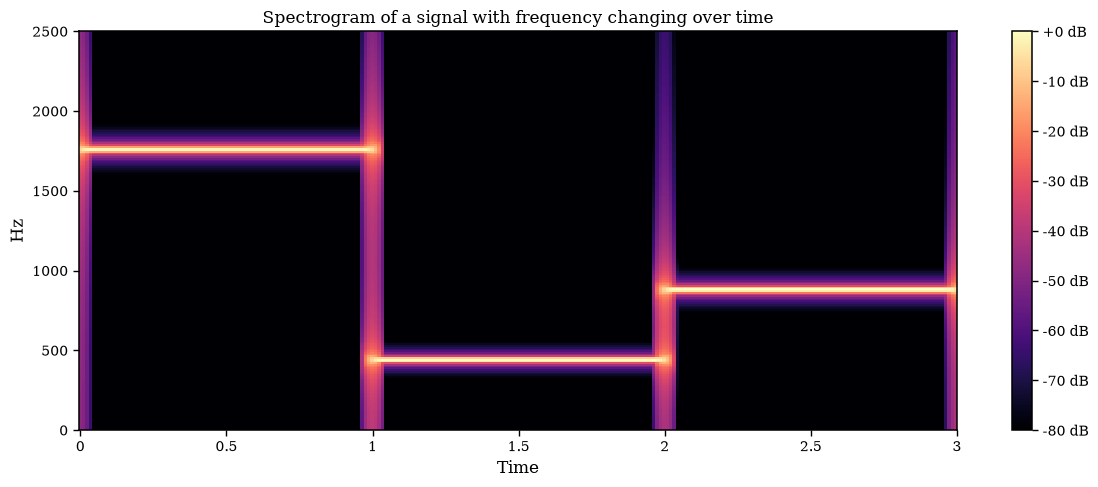

In [111]:
n_fft = 2048
hop_length = 256

S = librosa.stft(changing_signal, n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    S_db,
    sr=sampling_rate,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
)
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram of a signal with frequency changing over time")
plt.ylim(0, 2500)
plt.tight_layout()
plt.show()

### Interpretation

The spectrogram shows when each frequency occurs:

- the first segment contains approximately 440 Hz,
- the second segment contains approximately 880 Hz,
- the third segment contains approximately 1760 Hz.

This is the central advantage of the spectrogram:

> It shows frequency content as a function of time.

## Load a real audio example from ESC-50

Now we will compute the spectrogram of a real environmental sound from the ESC-50 subset.

In [112]:
metadata = pd.read_csv(SUBSET_METADATA)

selected_category = "sneezing" # "chirping_birds"
example = metadata[metadata["category"] == selected_category].iloc[0]

audio_path = PROJECT_ROOT / example["subset_audio_path"]

y, sr = librosa.load(audio_path, sr=None, mono=True)
duration = librosa.get_duration(y=y, sr=sr)

print("Selected category:", selected_category)
print("Filename:", example["filename"])
print("Sampling rate:", sr, "Hz")
print("Number of samples:", len(y))
print("Duration:", duration, "seconds")

Selected category: sneezing
Filename: 1-26143-A-21.wav
Sampling rate: 44100 Hz
Number of samples: 220500
Duration: 5.0 seconds


In [113]:
display(Audio(y, rate=sr))

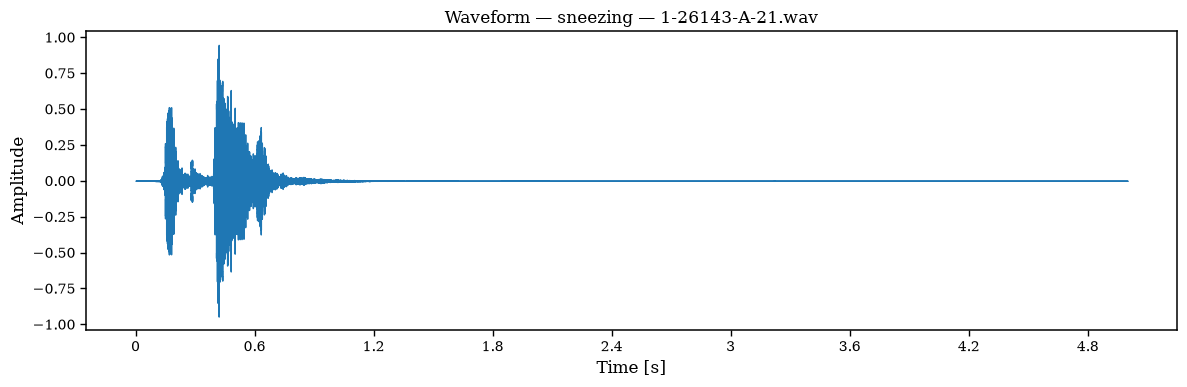

In [114]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform — {example['category']} — {example['filename']}")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Spectrogram of a real audio file

We now apply the STFT to the real audio example.

This allows us to see how its frequency content changes over time.

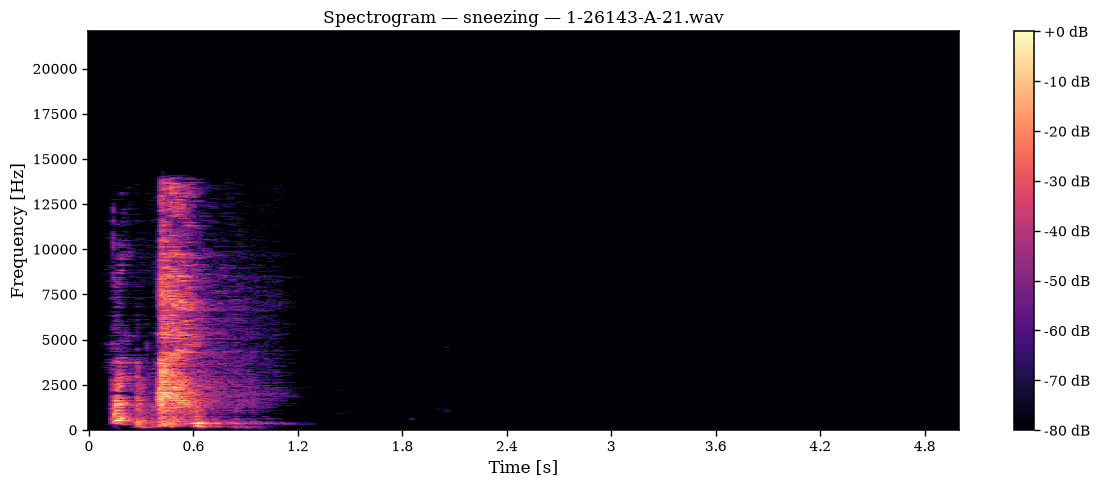

In [115]:
n_fft = 2048
hop_length = 512

S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Spectrogram — {example['category']} — {example['filename']}")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.tight_layout()
plt.show()

## Compare spectrograms from different classes

Different sound classes may have different time-frequency patterns.

For example:

- `rain` may look more continuous and broadband;
- `clock_tick` may show short impulsive events;
- `chirping_birds` may show narrow frequency components that change over time;
- `helicopter` may show lower-frequency periodic structure.

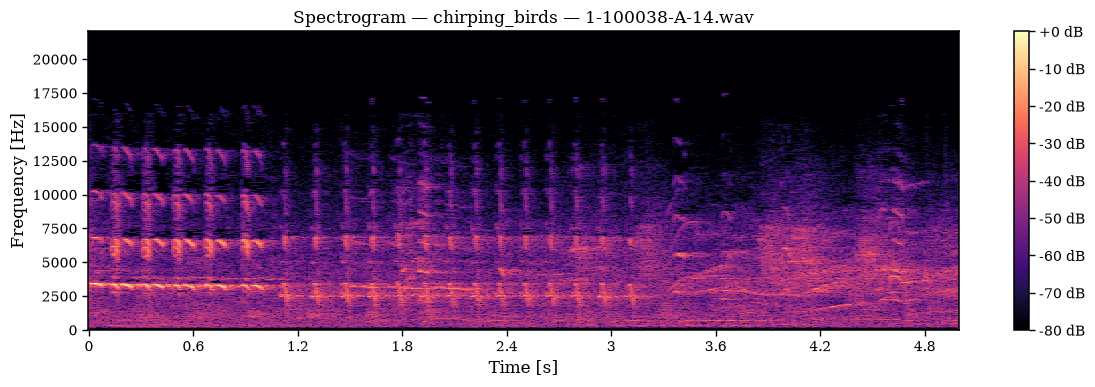

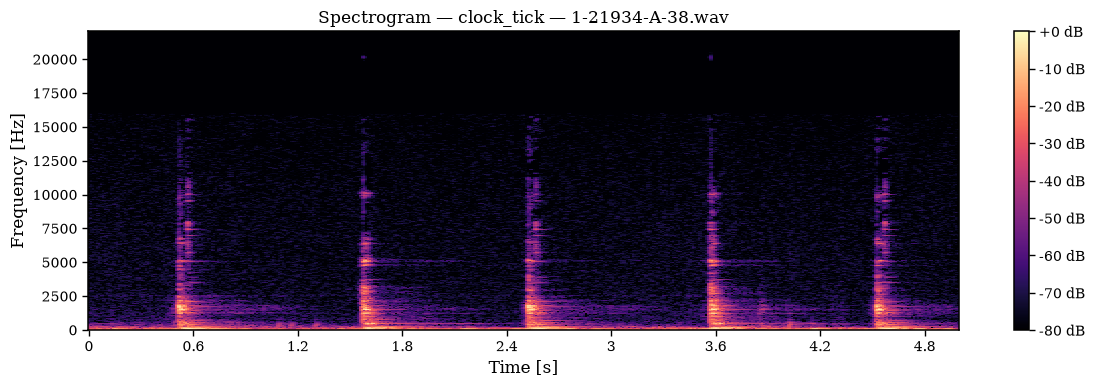

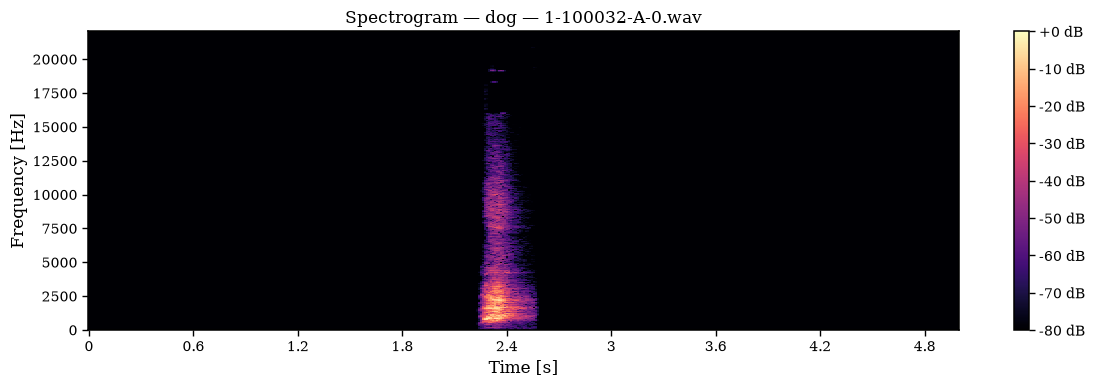

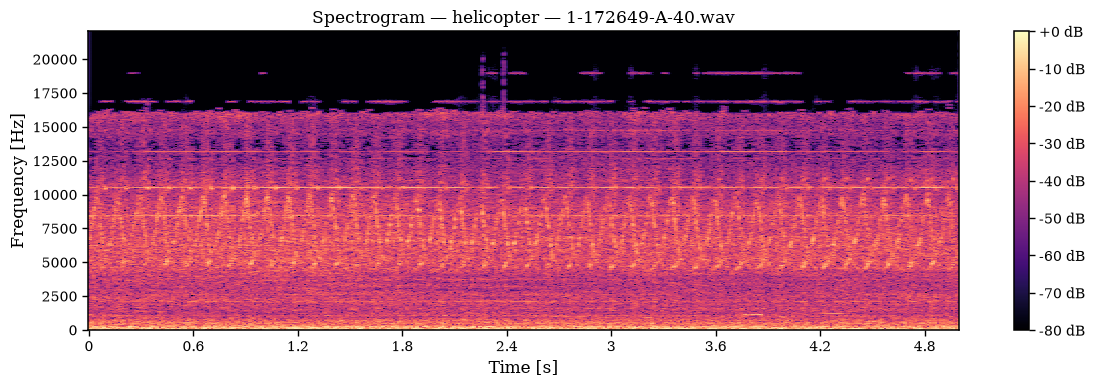

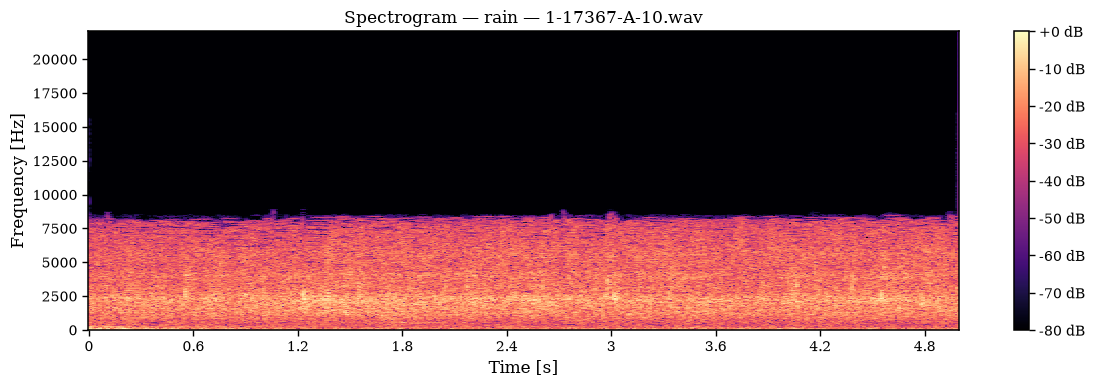

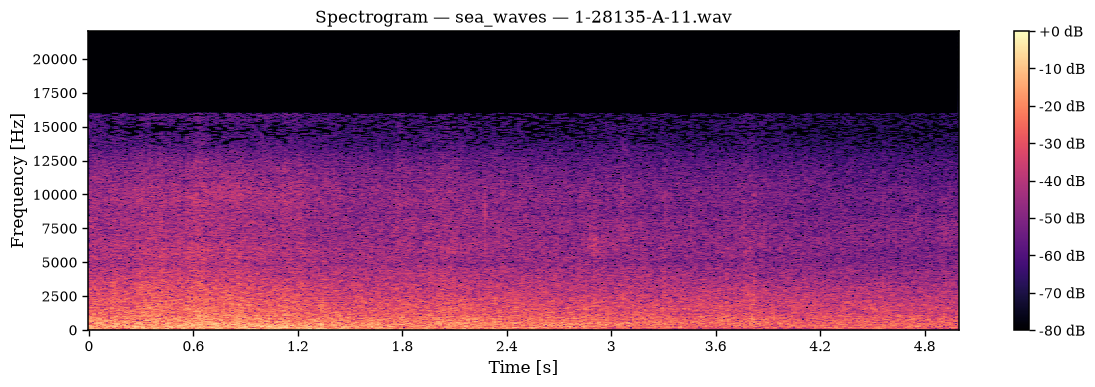

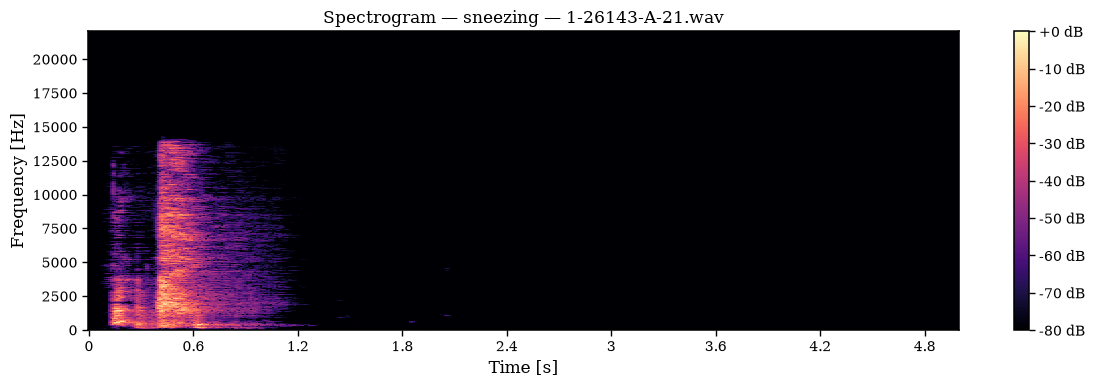

In [116]:
selected_categories = [
    "chirping_birds",
    "clock_tick",
    "dog",
    "helicopter",
    "rain",
    "sea_waves",
    "sneezing",
]

for category in selected_categories:
    row = metadata[metadata["category"] == category].iloc[0]
    audio_path = PROJECT_ROOT / row["subset_audio_path"]

    y_tmp, sr_tmp = librosa.load(audio_path, sr=None, mono=True)

    S = librosa.stft(y_tmp, n_fft=2048, hop_length=512)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        S_db,
        sr=sr_tmp,
        hop_length=512,
        x_axis="time",
        y_axis="hz",
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Spectrogram — {category} — {row['filename']}")
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.tight_layout()
    plt.show()

## Summary

In this notebook, we moved from time-domain analysis to time-frequency analysis.

Key ideas:

- A waveform shows how the signal amplitude changes over time.
- A spectrum shows which frequencies are present in the signal.
- The DFT is the discrete version of the Fourier Transform for digital signals.
- The FFT is an efficient algorithm to compute the DFT.
- The global FFT does not show when frequencies occur.
- The STFT applies the FFT to short time windows.
- A spectrogram visualizes how frequency content changes over time.

## Discussion questions

1. Why is the waveform not always enough to understand an audio signal?
2. What does a peak in the magnitude spectrum represent?
3. What information is lost when using a global FFT?
4. Why does the STFT use short overlapping windows?
5. How do the spectrograms differ across sound classes?
6. Which classes look more impulsive, tonal, or broadband in the spectrogram?